# Домашнее задание "Корреляционный и регрессионный анализ"

**Инструкции:**
- Скачайте файл `practical_module_dataset.csv` и заполните ячейки с заданиями кодом и выводами.
- В каждой задаче требуется:
  - короткая формулировка метода и обоснование,
  - код/расчёты,
  - результаты (коэффициенты, статистики, p-value, CI, R²),
  - промежуточный вывод.
- Используйте `numpy`, `pandas`, `scipy`, `statsmodels` или `scikit-learn` по желанию. При необходимости предобработки данных (очистка, удаление пропусков) укажите свои действия.
- Для воспроизводимости задан `np.random.seed` - не меняйте его!

**Формат сдачи:** `.ipynb` с заполненными ячейками, кодом и выводами.

In [34]:
# ячейка с импортами - дополняйте по своему желанию!
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
from scipy import stats
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, linregress

np.random.seed(28)

In [35]:
df = pd.read_csv('C:\IDE\Statistic\data\practical_module_dataset.csv')
df.shape
df.head()

<>:1: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
<>:1: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
C:\Users\troyd\AppData\Local\Temp\ipykernel_18492\781531574.py:1: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
  df = pd.read_csv('C:\IDE\Statistic\data\practical_module_dataset.csv')


,id,age,height_cm,weight_kg,iq,tv_hours,study_hours,score
0,1,24,155.2,51.37,91,11,11.9,76.5
1,2,37,184.9,76.49,90,15,4.0,65.4
2,3,32,169.8,64.24,98,6,10.6,78.2
3,4,28,173.6,68.22,88,9,9.2,75.6
4,5,25,174.2,73.80,102,8,8.0,75.1


### Задание 1.
Выполните первичный анализ данных (EDA):
1. посмотрите на `describe()` для всех переменных,
2. проверьте наличие пропусков и типы данных через `info()`,
3. запишите наблюдения в текстовой ячейке.

In [36]:
# Ваш код и расчёты

# Удалим столбец id, так как он неинформативен.

df.drop('id', axis=1, inplace=True)
df.describe()

,age,height_cm,weight_kg,iq,tv_hours,study_hours,score
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,29.400000,169.153333,62.734000,100.433333,12.266667,7.640000,73.400000
std,6.672641,9.584101,9.201488,12.119188,3.832109,3.281568,8.253693
min,18.000000,148.200000,44.750000,82.000000,6.000000,2.700000,58.900000
25%,24.250000,163.250000,56.622500,91.000000,9.000000,4.975000,67.800000
50%,29.000000,169.750000,63.675000,97.000000,12.000000,7.650000,74.300000
75%,35.500000,174.100000,68.602500,109.750000,14.000000,9.450000,78.725000
max,39.000000,185.800000,81.130000,132.000000,22.000000,14.400000,91.500000


In [37]:
# Ваш код и расчёты

display(df.isnull().sum())
df.info()

age            0
height_cm      0
weight_kg      0
iq             0
tv_hours       0
study_hours    0
score          0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          30 non-null     int64  
 1   height_cm    30 non-null     float64
 2   weight_kg    30 non-null     float64
 3   iq           30 non-null     int64  
 4   tv_hours     30 non-null     int64  
 5   study_hours  30 non-null     float64
 6   score        30 non-null     float64
dtypes: float64(4), int64(3)
memory usage: 1.8 KB


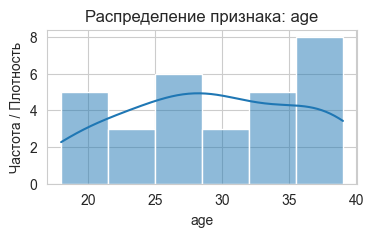

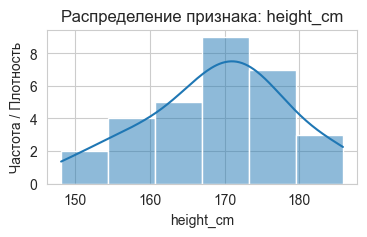

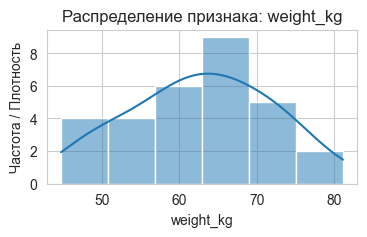

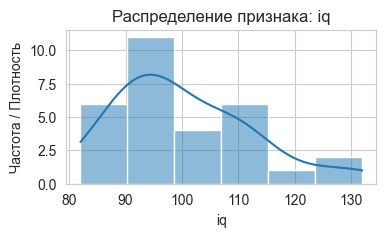

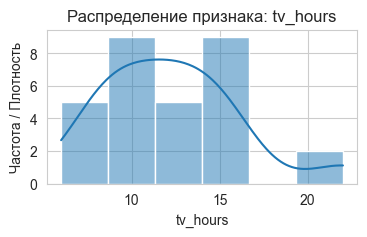

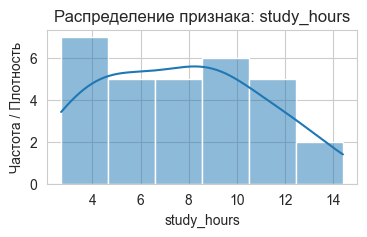

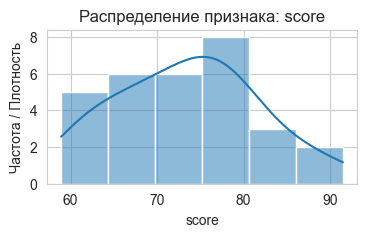

In [38]:
for column in df.columns:
    # Создаем новый график для каждого столбца
    plt.figure(figsize=(4, 2)) 
    
    # Строим график 
    sns.histplot(data=df, x=column, kde=True)
    
    # Добавляем заголовок, используя имя столбца
    plt.title(f'Распределение признака: {column}')
    plt.xlabel(column)
    plt.ylabel('Частота / Плотность')
    
    # Показываем текущий график
    plt.show()

### ответы, рассуждения и выводы

Выполните первичный анализ данных (EDA):

1. Был удален столбец "id", так как он является уникальным для каждого наблюдения и не несет какой-либо информативности. 

2. Пропуски в данных отсутствуют. Все столбцы представлены в числовом виде, 4 столбца признаков имеют тип данных float64, 3 столбца int64.

3. 
3.1.Оценка симметрии:

Столбцы 'age', 'weight_kg', распределены достатоно симметрично, близко к нормальному.

Столбец 'height_cm' распределение достатоно симметрично, близко к нормальномуимеет, имеет небольшой скос влево.

Столбцы 'iq', 'tv_hours', 'study_hours','score' распределены со скосом вправо.

3.2. Оценка наличия выбросов:

В столбцах 'iq', 'tv_hours' присутствуют значения, отличающиеся от основного тела графика, крайние правые столбцы гистограмм, возможно являются выбросами.

### Задание 2.
1. Постройте scatter plot по признакам `height_cm` и `weight_kg`.
2. Посчитайте коэффициент Пирсона между `height_cm` и `weight_kg` и выведите его на экран.
3. Интерпретируйте результат и запишите в виде мини-вывода.

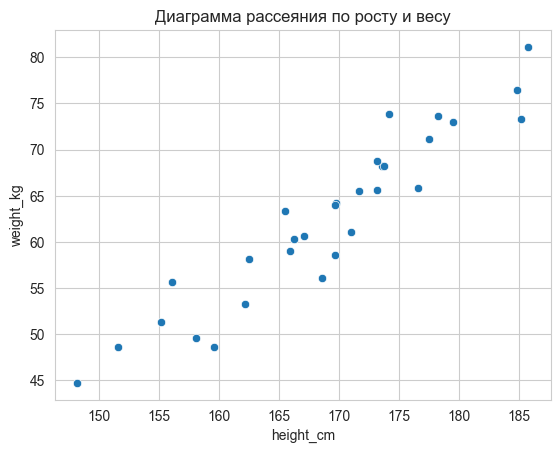

In [39]:
# Ваш код и расчёты. 1. Постройте scatter plot по признакам `height_cm` и `weight_kg`.

sns.scatterplot(data=df, x='height_cm', y='weight_kg')

plt.title('Диаграмма рассеяния по росту и весу')
plt.show()

In [43]:
# Ваш код и расчёты. 2. Посчитайте коэффициент Пирсона между `height_cm` и `weight_kg` и выведите его на экран.

r, pval_r = pearsonr(df['height_cm'], df['weight_kg'])

print(f"Pearson r = {r:.3f}, p = {pval_r:.3e}")

n = df['height_cm'].size
t_stat = r / np.sqrt((1 - r**2) / (n - 2))
print(f"t = {t_stat:.3f}, df = {n-2}")

alpha = 0.05  # Уровень значимости 


# Расчет критического значения
# Для двустороннего теста используется вероятность 1 - alpha/2
q_value = 1 - alpha / 2
t_critical = stats.t.ppf(q=q_value, df=n-2)

round(t_critical, 3)

Pearson r = 0.944, p = 5.799e-15
t = 15.071, df = 28


np.float64(2.048)

### ответы, рассуждения и выводы

По графику наблюдается прямая линейная связь между признаками height_cm и weight_kg. Значимых выбросов не наблюдается. Коэффициент Пирсона близок к единице Pearson r = 0.944, что также подтверждает прямую линейгую зависимость. Для уровня значимости 0,05 и степни свободы 28 критическое двустороннее значение t = 2,048, что меньше значения t-статистики. Это дает нам основания отвергнуть нулевую гипотезу о том, что связь между наблюдаемыми признаками не имеет значения. p-value также < 0,05. Следовательно наблюдаемая положительная корреляция статистически значима.

### Задание 3.
1. Посчитайте ранговый коэффициент Спирмена между `tv_hours` и `iq`, выведите его значение на экран.
2. Оцените, есть ли связь? Запишите наблюдения в виде короткого вывода.

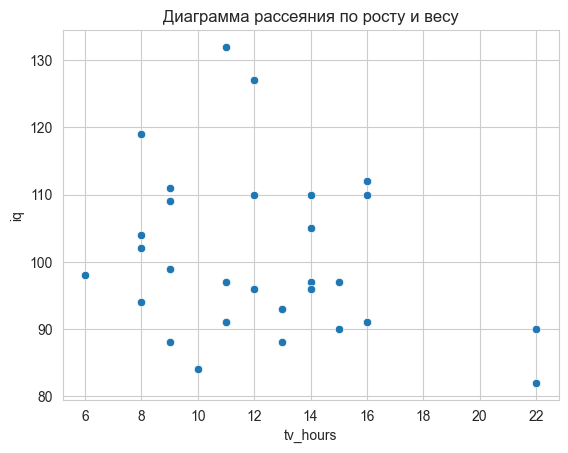

In [44]:
# Ваш код и расчёты
sns.scatterplot(data=df, x='tv_hours', y='iq')

plt.title('Диаграмма рассеяния по росту и весу')
plt.show()

In [47]:
# Ваш код и расчёты
rho, pval = stats.spearmanr(df['tv_hours'], df['iq'])
print(f"Spearman rho = {rho:.3f}, p-value = {pval:.3f}")

def perm_test_spearman(x, y, B=10000, seed=1):
    rng = np.random.default_rng(seed)
    obs = stats.spearmanr(x, y).correlation
    count = 0
    for _ in range(B):
        y_perm = rng.permutation(y)
        if abs(stats.spearmanr(x, y_perm).correlation) >= abs(obs):
            count += 1
    return (count+1)/(B+1)

p_perm = perm_test_spearman(df['tv_hours'], df['iq'], B=5000)
print("Permutation p-value (two-sided):", p_perm)

Spearman rho = -0.211, p-value = 0.264
Permutation p-value (two-sided): 0.26514697060587883


### ответы, рассуждения и выводы

По графику зависимости tv_hours от iq не наблюдается линейной зависимости, также в распределении признаков были значения, потенциально являющиеся выбросами. Spearman rho = -0.211 что указывает слабую обратную монотонную связь признаков. Значение p-value = 0.264, при расчете коэффициента Спирмена, а также Permutation p-value (two-sided): 0.265, вычисленное при перестановочном тесте показывает идентичные результаты. p-value = 0.264 > уровня значимости 0,05, из чего можно сделать вывод, что наблюдаемая корреляция статистичски не значима.

### Задание 4.
1. Постройте простую линейную регрессию `weight_kg ~ height_cm`.
2. Найдите и выведите оценки коэффициентов (intercept и slope).
3. Рассчитайте и вывдите 95% доверительный интервал для наклона.
4. Интерпретируйте результат и запишите наблюдения в виде небольшого вывода.

In [76]:
# Ваш код и расчёты. 1. Постройте простую линейную регрессию `weight_kg ~ height_cm`.

import numpy as np

n = df['weight_kg'].size
xbar, ybar = df['height_cm'].mean(), df['weight_kg'].mean()
Sxx = np.sum((df['height_cm'] - xbar)**2)
Sxy = np.sum((df['height_cm'] - xbar)*(df['weight_kg'] - ybar))

# 2. Найдите и выведите оценки коэффициентов (intercept и slope).
b1 = Sxy / Sxx
b0 = ybar - b1*xbar
print("intercept:", round(b0, 3))
print('-'*30)
print("slope:", round(b1, 3))


y_pred = b0 + b1*df['height_cm']
resid = df['weight_kg'] - y_pred
SSE = np.sum(resid**2)
s2 = SSE/(n-2)
se_b1 = np.sqrt(s2 / Sxx)

X = sm.add_constant(df['height_cm'])   # добавляем константу для intercept
model = sm.OLS(df['weight_kg'], X).fit()
print('-'*30)
print(model.summary())



intercept: -90.496
------------------------------
slope: 0.906
------------------------------
                            OLS Regression Results                            
Dep. Variable:              weight_kg   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     227.1
Date:                Sun, 07 Dec 2025   Prob (F-statistic):           5.80e-15
Time:                        13:54:14   Log-Likelihood:                -75.497
No. Observations:                  30   AIC:                             155.0
Df Residuals:                      28   BIC:                             157.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

In [77]:
# Ваш код и расчёты

# 3. Рассчитайте и вывдите 95% доверительный интервал для наклона.
# 95% CI for slope
from scipy.stats import t
tcrit = t.ppf(0.975, n-2)
ci_b1 = (float(round(b1 - tcrit*se_b1, 3)), float(round(b1 + tcrit*se_b1, 3)))

print('-'*30)
print("95% CI for slope:", [ci_b1[0],  ci_b1[1]])

------------------------------
95% CI for slope: [0.783, 1.029]


### ответы, рассуждения и выводы

intercept: -90.496

slope: 0.906

intercept: -90.496 отрицательный, это означает, что модель прогнозирует отрицательное значение weight_kg при height_cm = 0.

Значение наклона, slope = 0.906, это значит, что при увеличении weight_kg на одну единицу, height_cm изменится на 0.906.

95% CI for slope: [0.783, 1.029], говорит о том, что можно быть на 95% увереным, что истинное среднее изменение height_cm при увеличении weight_kg на единицу лежит в диапазоне от 0.783 до 1.029. Так как CI не содержит нуль, связь между признаками статистически значима. 


### Задание 5.
Для `height_cm = 175`:
1. вычислите предсказание веса,
2. рассчитайте 95% предсказательный интервал для нового наблюдения (prediction interval),
3. запишите небольшой вывод.

In [78]:
# Ваш код и расчёты

# предсказание и интервал для x0
x0 = np.array([1, 175])   # [const, x0]
pred = model.get_prediction(x0)
pred.predicted_mean

array([68.03029563])

In [79]:
# Ваш код и расчёты
print(pred.summary_frame(alpha=0.05))  # mean, mean_ci_lower/upper, obs_ci_lower/upper

        mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  68.030296  0.666548      66.664933      69.395658     61.530687   

   obs_ci_upper  
0     74.529904  


### ответы, рассуждения и выводы

При height_cm = 175, модель предсказывает значение weight_kg 68.03029563.

95% CI for slope: [61.530687, 74.529904], говорит о том, что можно быть на 95% увереным, что истинное среднее значение weight_kg при height_cm = 175 лежит в диапазоне от 61.530687 до 74.529904. 

### Задание 6.
1. Постройте множественную регрессию `score ~ study_hours + iq + tv_hours + age`.
2. Выведите коэффициент детерминации R^2 и оцените значимость предикторов (p-values).
3. Запишите наблюдения в вывод.

In [80]:
# Ваш код и расчёты

df_X = df[['study_hours', 'iq', 'tv_hours', 'age']]
df_Y = df['score']

# OLS
X = sm.add_constant(df_X)
y = df_Y
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.874
Model:                            OLS   Adj. R-squared:                  0.854
Method:                 Least Squares   F-statistic:                     43.38
Date:                Sun, 07 Dec 2025   Prob (F-statistic):           6.73e-11
Time:                        15:07:14   Log-Likelihood:                -74.299
No. Observations:                  30   AIC:                             158.6
Df Residuals:                      25   BIC:                             165.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          45.6584      6.807      6.708      

In [86]:
# Ваш код и расчёты


print("коэффициент детерминации R^2:", model.rsquared)
print('-'*30)
print("p-values:", model.pvalues)
print('-'*30)
print("std err:", model.bse)



коэффициент детерминации R^2: 0.87407292249435
------------------------------
p-values: const          4.979884e-07
study_hours    6.056409e-11
iq             1.005923e-02
tv_hours       3.701764e-01
age            6.141056e-01
dtype: float64
------------------------------
std err: const          6.806993
study_hours    0.193392
iq             0.053118
tv_hours       0.158558
age            0.091130
dtype: float64


<Ваши ответы, рассуждения и выводы>

1. Коэффициент детерминации R^2: 0.87407292249435 показывает, какую долю дисперсии зависимой переменной score объясняют независимые переменные (предикторы) модели. Значение от 0 до 1, в нашем случае значение близко к единице, значит модель достаточно хорошо описывает значение зависимой переменной

2. Чтобы можно было сделать вывод о статистической значимости влияния отдельного предиктора на значение зависимой переменной, нужно оценить значение p-value каждого предиктора. 

У предикторов study_hours и iq значения p-value меньше порога значимости 0,05, значит влияние данных предикторов статистически значимо, они оказывают влияние на зависимую переменную.

У предикторов tv_hours и age значения p-value больше порога значимости 0,05, значит влияние данных предикторов статистически не значимо, они не оказывают существенного влияния на зависимую переменную.

### Задание 7.
1. Разделите данные на train/test (70/30), используйте `random_state=42`.
2. Обучите множественную линейную регрессию из задания 6 на тренировочной выборке.
3. И оцените RMSE на тестовой выборке - выведите её на экран.
4. Насколько модель хорошо предсказывает целевую переменную?

In [88]:
# Ваш код и расчёты

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.3, 
    random_state=42,
    shuffle=True
)

model = sm.OLS(y_train, X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.906
Model:                            OLS   Adj. R-squared:                  0.883
Method:                 Least Squares   F-statistic:                     38.76
Date:                Sun, 07 Dec 2025   Prob (F-statistic):           4.84e-08
Time:                        15:27:43   Log-Likelihood:                -49.577
No. Observations:                  21   AIC:                             109.2
Df Residuals:                      16   BIC:                             114.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          46.0369      6.960      6.614      

In [91]:
# Ваш код и расчёты

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

print(f"RMSE на тестовой выборке: {rmse}")
print('-'*30)
print("коэффициент детерминации R^2:", model.rsquared)



RMSE на тестовой выборке: 3.7935539803776614
------------------------------
коэффициент детерминации R^2: 0.9064487772840303


### ответы, рассуждения и выводы

Значение RMSE на тестовой выборке: 3.7935539803776614. RMSE измеряется в тех же единицах, что и целевая переменная. Чем меньше RMSE, тем лучше модель. RMSE показывает насколько единиц в среднем модель ошибается при предсказании. Среднее значение зависимой переменной score из датасета 73,4. Среднее значение ошибки составляет 5,17 % от среднего значения зависимой переменной. Можно сделать вывод, что модель предсказывает значение зависимой переменной хорошо, в среднем ошибаясь на 5,17 %.

### Задание 8.
1. Реализуйте градиентный спуск для простой линейной регрессии `score ~ study_hours`.
2. Сравните полученные коэффициенты со `statsmodels`.

PS: выведите коэффициенты в обоих случаях на экран.

In [101]:
# Ваш код и расчёты
x = df['study_hours']
y = df['score']
# инициализация
w = 0.0
b = 0.0
eta = 0.01
n_iter = 3900
n = len(x)

for epoch in range(n_iter):
    # предсказание
    y_hat = w * x + b
    # градиенты для MSE (с фактором 2/n)
    grad_w = (-2.0/n) * np.sum(x * (y - y_hat))
    grad_b = (-2.0/n) * np.sum(y - y_hat)
    # обновление
    w -= eta * grad_w
    b -= eta * grad_b

print("w, b:", round(w,3), round(b,3))  # ожидаем примерно w≈2, b≈1

w, b: 2.273 56.034


In [93]:
# Ваш код и расчёты

X = sm.add_constant(df['study_hours'])   # добавляем константу для intercept
model = sm.OLS(y, X).fit()
print('-'*30)
print(model.summary())

------------------------------
                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.817
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     124.8
Date:                Sun, 07 Dec 2025   Prob (F-statistic):           7.92e-12
Time:                        16:04:16   Log-Likelihood:                -79.928
No. Observations:                  30   AIC:                             163.9
Df Residuals:                      28   BIC:                             166.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          56.0

### ответы, рассуждения и выводы

Коэффициенты w = 2.273, b= 56.034, получены при реализации градиентного спуска. С помощью OLS получены соответсвтующие им коэффициенты study_hours = 2.2730, const = 56.0340. Результаты идентичны. Для достижения таких результатов градиентному спуску понадобилось 3900 итераций с шагом обучения 0,01.

### Задание 9.
Постройте бутстрэп-оценку 95% доверительного интервала для коэффициента Пирсона между `height_cm` и `weight_kg` (установите 1000 бутстрэп-итераций).

Выведите границы ДИ на экран.

In [ ]:
# Ваш код и расчёты

original_corr, _ = pearsonr(df['height_cm'], df['weight_kg'])
print(f"Исходный коэффициент Пирсона R: {original_corr:.4f}")

n_iterations = 1000
bootstrapped_cors = []
n_samples = len(df)

for _ in range(n_iterations):
    # Случайная выборка индексов с заменой
    sample_indices = np.random.choice(range(n_samples), size=n_samples, replace=True)
    
    # Извлечение данных по индексам, сохраняя пары (height, weight)
    sample_x = df['height_cm'].iloc[sample_indices].values
    sample_y = df['weight_kg'].iloc[sample_indices].values
    
    # Расчет коэффициента корреляции для текущей бутстрэп-выборки
    sample_corr, _ = pearsonr(sample_x, sample_y)
    bootstrapped_cors.append(sample_corr)

# Преобразование списка результатов в массив numpy 
bootstrapped_cors = np.array(bootstrapped_cors)

Исходный коэффициент Пирсона R: 0.9435


In [104]:
# Ваш код и расчёты

lower_bound = np.percentile(bootstrapped_cors, 2.5)
upper_bound = np.percentile(bootstrapped_cors, 97.5)

print(f"Нижняя граница 95% CI: {lower_bound:.4f}")
print(f"Верхняя граница 95% CI: {upper_bound:.4f}")

Нижняя граница 95% CI: 0.9021
Верхняя граница 95% CI: 0.9705


### ответы, рассуждения и выводы

Для `height_cm` и `weight_kg` 95% доверительный интервал для коэффициента Пирсона составляет  от 0.9021 до 0.9705. Доверительный интервал не включает ноль. Это говорит о том, что рост и вес в  датасете  очень тесно связаны линейной зависимостью, а также что корреляция является статистически значимой. Вывод о наличии связи между ростом и весом очень надежен.

### Задание 10.
Постройте гистограмму остатков (residuals) для модели из задания 6.

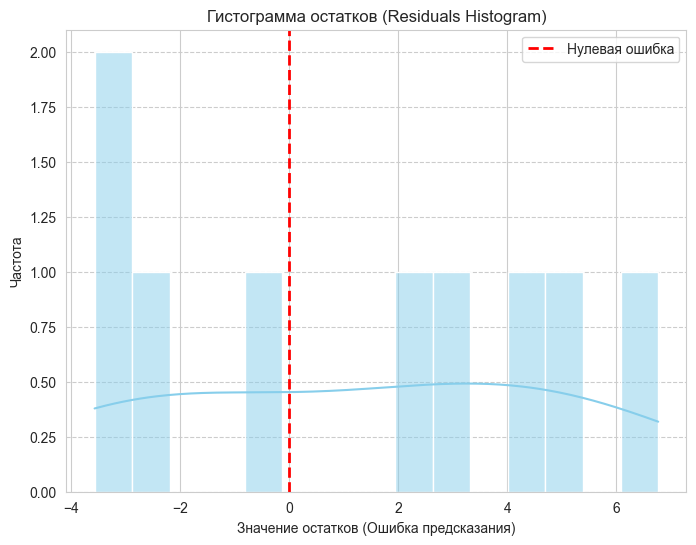

In [107]:
# Ваш код и расчёты
residuals = y_test - y_pred

# --- 2. Построение гистограммы с линией плотности (KDE) ---
plt.figure(figsize=(8, 6))

# Используем seaborn для красивой гистограммы
sns.histplot(residuals, kde=True, bins=15, color='skyblue')

plt.title('Гистограмма остатков (Residuals Histogram)')
plt.xlabel('Значение остатков (Ошибка предсказания)')
plt.ylabel('Частота')
plt.grid(True, axis='y', linestyle='--')
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Нулевая ошибка')
plt.legend()
plt.show()

### ответы, рассуждения и выводы

Гистограмма остатков помогает оценить нормальность распределения остатков, так как это один из важнейших показателей качества модели линейной регрессии. В идеале гистограмма остатков должна иметь нормальное распределние, пик распределения должен быть в нуле. В нашем случае распределние равномерное, с пиком левее нуля. Это может значить, что модель плохо улавливает закономерности и ошибки распределены хаотично.

Удачи! Сохраните ноутбук, перезапустите все ячейки от начала до конца и прикрепите файл как ответ.